In [95]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import confusion_matrix,accuracy_score,roc_curve,auc,classification_report,RocCurveDisplay

In [96]:
#read and inspect data
df= pd.read_csv("data.csv",index_col=0)
print(df.head())

   location  country  gender   age  vis_wuhan  from_wuhan  symptom1  symptom2  \
0       104        8       1  66.0          1           0        14        31   
1       101        8       0  56.0          0           1        14        31   
2       137        8       1  46.0          0           1        14        31   
3       116        8       0  60.0          1           0        14        31   
4       116        8       1  58.0          0           0        14        31   

   symptom3  symptom4  symptom5  symptom6  diff_sym_hos  result  
0        19        12         3         1             8       1  
1        19        12         3         1             0       0  
2        19        12         3         1            13       0  
3        19        12         3         1             0       0  
4        19        12         3         1             0       0  


In [97]:
data_length=len(df)
print(data_length)
print(df["result"].value_counts())

863
result
0    755
1    108
Name: count, dtype: int64


In [98]:
X=df.drop("result",axis=1)
print(X.head())

   location  country  gender   age  vis_wuhan  from_wuhan  symptom1  symptom2  \
0       104        8       1  66.0          1           0        14        31   
1       101        8       0  56.0          0           1        14        31   
2       137        8       1  46.0          0           1        14        31   
3       116        8       0  60.0          1           0        14        31   
4       116        8       1  58.0          0           0        14        31   

   symptom3  symptom4  symptom5  symptom6  diff_sym_hos  
0        19        12         3         1             8  
1        19        12         3         1             0  
2        19        12         3         1            13  
3        19        12         3         1             0  
4        19        12         3         1             0  


In [99]:
y=df['result']
print(y.head())

0    1
1    0
2    0
3    0
4    0
Name: result, dtype: int64


In [100]:
#split data into 0.2 test data,0.2 validation data,0.6 train data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=1) 

In [101]:
y_train.value_counts()
#class 0 is over-represented so we over-sample the minority class (class 1)

result
0    453
1     64
Name: count, dtype: int64

In [102]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_train, y_train = ros.fit_resample(X_train, y_train)

In [103]:
print(y_train.value_counts())
#data is now balanced

result
0    453
1    453
Name: count, dtype: int64


Decision Trees
-

In [104]:
#fit the data
from sklearn.tree import DecisionTreeClassifier
dtree=DecisionTreeClassifier()
dtree.fit(X_train,y_train)

DecisionTreeClassifier()

In [105]:
#predict the data
y_val_predict_dt=dtree.predict(X_val)
print(y_val_predict_dt)

[0 0 1 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]


In [106]:
print ("Decision tree Metrics")
print(classification_report(y_val,y_val_predict_dt))
print('\n')
print(confusion_matrix(y_val,y_val_predict_dt))

Decision tree Metrics
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       149
           1       0.89      0.71      0.79        24

    accuracy                           0.95       173
   macro avg       0.92      0.85      0.88       173
weighted avg       0.95      0.95      0.95       173



[[147   2]
 [  7  17]]


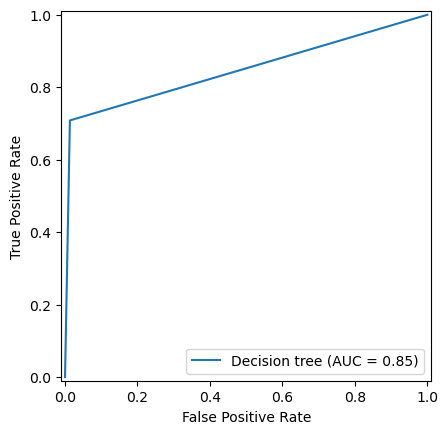

In [107]:
#extract probabilities of entry classification
y_proba_dt = dtree.predict_proba(X_val)[:, 1]
# Calculate FPR, TPR, thresholds
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_val, y_proba_dt)
# Calculate auc
roc_auc_dt = auc(fpr_dt, tpr_dt)
#display
display_dt = RocCurveDisplay(fpr=fpr_dt, tpr=tpr_dt, roc_auc=roc_auc_dt,estimator_name='Decision tree')

display_dt.plot()
plt.show()

Hyperparameter Tuning of Decision tree model
-

In [108]:
#using Grid search
from sklearn.model_selection import GridSearchCV

param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 20, 50],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10, 20],
    'max_features': [None, 'sqrt', 'log2'],
    'max_leaf_nodes': [None, 10, 20, 50, 100]
}

# Perform grid search
grid_search_dt = GridSearchCV(estimator=dtree, param_grid=param_grid_dt, cv=5,scoring = 'recall') #to catch all positives
grid_search_dt.fit(X_train, y_train)

# Best parameters and score
print("Best Parameters:", grid_search_dt.best_params_)
print("Best Cross-Validation Score:", grid_search_dt.best_score_)

# Use the best model for predictions
best_dt = grid_search_dt.best_estimator_
y_val_predict_best_dt = best_dt.predict(X_val)

Best Parameters: {'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-Validation Score: 1.0


In [109]:
#display some metrics
print('Decision tree Metrics after tuning hyper parameters')
print(classification_report(y_val,y_val_predict_best_dt))
print('\nConfusion matrix')
print(confusion_matrix(y_val,y_val_predict_best_dt))

Decision tree Metrics after tuning hyper parameters
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       149
           1       0.89      0.71      0.79        24

    accuracy                           0.95       173
   macro avg       0.92      0.85      0.88       173
weighted avg       0.95      0.95      0.95       173


Confusion matrix
[[147   2]
 [  7  17]]


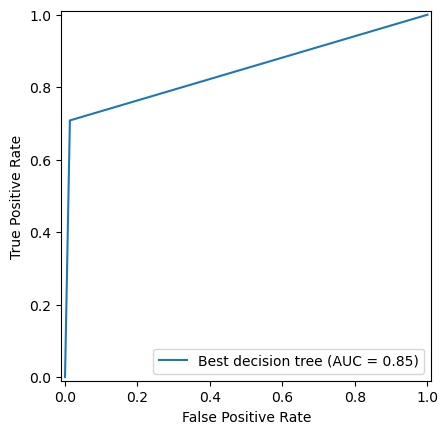

In [110]:
#extract probabilities of entry classification
y_proba_best_dt = best_dt.predict_proba(X_val)[:, 1]
# Calculate FPR, TPR, thresholds
fpr_best_dt, tpr_best_dt, thresholds_best_dt = roc_curve(y_val, y_proba_best_dt)
# Calculate auc
roc_auc_best_dt = auc(fpr_best_dt, tpr_best_dt)
#display
display_best_dt = RocCurveDisplay(fpr=fpr_best_dt, tpr=tpr_best_dt, roc_auc=roc_auc_best_dt,estimator_name='Best decision tree')

display_best_dt.plot()
plt.show()

In [111]:
y_test_predict_dt=best_dt.predict(X_test)
print(y_test_predict_dt)

[0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 1 0 1 1 0 0 0 1 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 1 0 0 0 0 0 0]


In [112]:
#display some metrics
print('best decision tree Metrics using test data')
print(classification_report(y_test,y_test_predict_dt))
print('\nConfusion matrix')
print(confusion_matrix(y_test,y_test_predict_dt))

best decision tree Metrics using test data
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       153
           1       0.89      0.80      0.84        20

    accuracy                           0.97       173
   macro avg       0.93      0.89      0.91       173
weighted avg       0.96      0.97      0.96       173


Confusion matrix
[[151   2]
 [  4  16]]


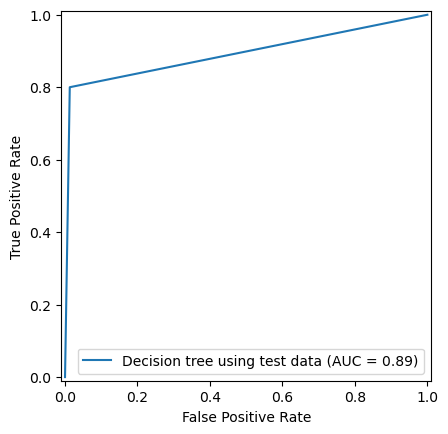

In [113]:
#extract probabilities of entry classification
y_proba_dt2 = best_dt.predict_proba(X_test)[:, 1]
#Calculate FPR, TPR, thresholds
fpr_dt2, tpr_dt2, thresholds_dt2 = roc_curve(y_test, y_proba_dt2)
# Calculate auc
roc_auc_dt2 = auc(fpr_dt2, tpr_dt2)
#display
display_dt2 = RocCurveDisplay(fpr=fpr_dt2, tpr=tpr_dt2, roc_auc=roc_auc_dt2,estimator_name='Decision tree using test data')

display_dt2.plot()
plt.show()